# Tarea 3

In [1]:
import numpy as np
import tensorflow as tf 
import matplotlib.pyplot as plt

## 1. Capa que transforma a escala de grises

In [2]:
class GrayscaleLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # Convierte RGB a Grayscale
        return tf.image.rgb_to_grayscale(inputs)

    def get_config(self):
        return super().get_config()

In [3]:
gray_test = tf.keras.Sequential([
    GrayscaleLayer(input_shape=(28,28,3))
])

/var/folders/sl/_0vv98412kq54qbqdd087ztw0000gn/T/ipykernel_7764/3904519066.py:3: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
gray_test.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ grayscale_layer                 │ (None, 28, 28, 1)      │             0 │
│ (GrayscaleLayer)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
x = tf.random.uniform((1, 28, 28, 3))

y = gray_test(x)

print(x.shape)
print(y.shape)

(1, 28, 28, 3)
(1, 28, 28, 1)


(28, 28, 3)
(1, 28, 28, 1)


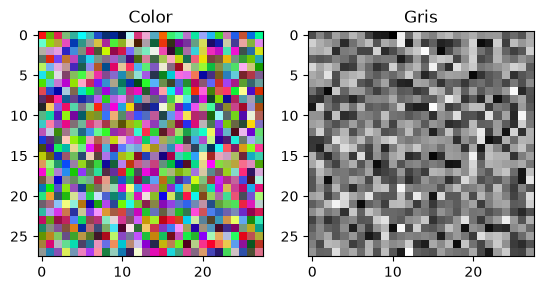

In [6]:
img = x[0]
print(img.shape)
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Color")
print(y.shape)
plt.subplot(1,2,2)
plt.imshow(y[0, :, :, 0], cmap="gray")
plt.title("Gris")

plt.show()

## 2. Aproximacion de funciones

In [7]:
space = np.linspace(0,1,100)
fun_a = 3*np.sin(np.pi *space)
fun_b = 1+2*space+ +4*(space**3)

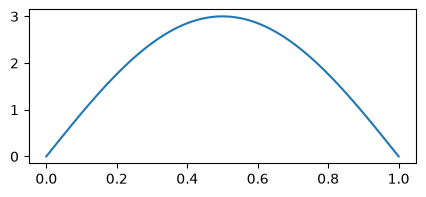

In [8]:
plt.figure(figsize=(5,2))
plt.plot(space,fun_a)

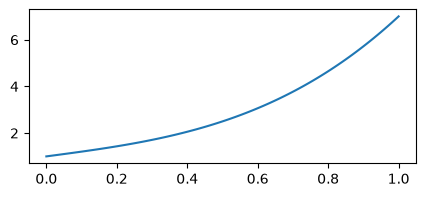

In [9]:
plt.figure(figsize=(5,2))
plt.plot(space,fun_b)

In [10]:
def crear_modelo():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='tanh', input_shape=(1,)),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

In [11]:
model_a = crear_modelo()

history_a = model_a.fit(
    space,
    fun_a,
    epochs=300,
    verbose=0
)

/Users/marcosbautista/uni/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


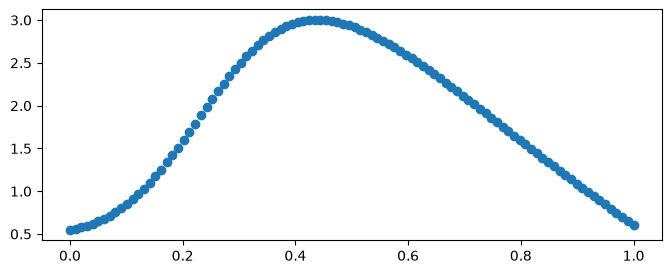

In [12]:
y_pred_a = model_a.predict(space, verbose=0)

plt.figure(figsize=(8,3))
plt.scatter(space,y_pred_a)

In [13]:
model_b = crear_modelo()

history_b = model_b.fit(
    space,
    fun_b,
    epochs=800,
    verbose=0
)

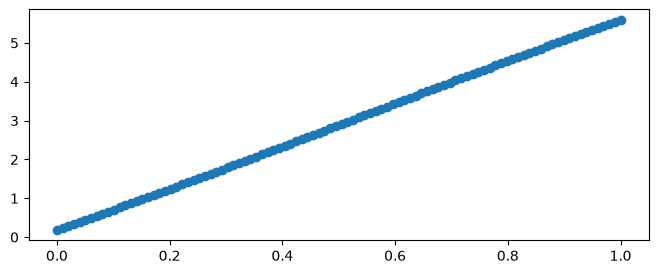

In [14]:
y_pred_b = model_b.predict(space, verbose=0)

plt.figure(figsize=(8,3))
plt.scatter(space,y_pred_b)

## 3. Capa entrenable de polinmoios de grado 3 

In [15]:
class PolynomialLayer(tf.keras.layers.Layer):

    def build(self, input_shape):

        self.a0 = self.add_weight(
            shape=(1,),
            initializer="random_normal",
            trainable=True,
            name="a0"
        )

        self.a1 = self.add_weight(
            shape=(1,),
            initializer="random_normal",
            trainable=True,
            name="a1"
        )

        self.a2 = self.add_weight(
            shape=(1,),
            initializer="random_normal",
            trainable=True,
            name="a2"
        )

        self.a3 = self.add_weight(
            shape=(1,),
            initializer="random_normal",
            trainable=True,
            name="a3"
        )

    def call(self, x):

        return (
            self.a0 +
            self.a1 * x +
            self.a2 * x**2 +
            self.a3 * x**3
        )

In [16]:
x_train = np.linspace(-1, 1, 1000).reshape(-1,1)
y_train = np.cos(2*x_train)

In [17]:
polinomial_model = tf.keras.Sequential([
    PolynomialLayer(input_shape=(1,))
])

polinomial_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.01),
    loss="mse"
)

/var/folders/sl/_0vv98412kq54qbqdd087ztw0000gn/T/ipykernel_7764/2323339159.py:2: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  PolynomialLayer(input_shape=(1,))


In [18]:
polinomial_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ polynomial_layer                │ (None, 1)              │             4 │
│ (PolynomialLayer)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = polinomial_model.fit(
    x_train,
    y_train,
    epochs=500,
    verbose=0
)

In [20]:
poly_layer = polinomial_model.layers[0]

print("a0 =", poly_layer.a0.numpy()[0])
print("a1 =", poly_layer.a1.numpy()[0])
print("a2 =", poly_layer.a2.numpy()[0])
print("a3 =", poly_layer.a3.numpy()[0])

a0 = 0.9519399
a1 = -0.010361914
a2 = -1.4896218
a3 = -0.0022369425


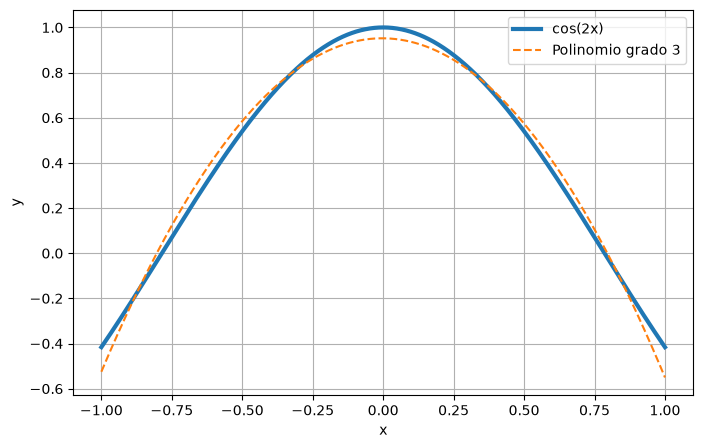

In [21]:
y_pred_polinomial = polinomial_model.predict(x_train, verbose=0)

plt.figure(figsize=(8,5))

plt.plot(x_train,y_train,label="cos(2x)",linewidth=3
)

plt.plot(x_train,y_pred_polinomial,"--",label="Polinomio grado 3"
)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

## 4.Solucion numerica de ED

### A)

In [43]:
model_ED = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='tanh', input_shape=(1,)),
    tf.keras.layers.Dense(32, activation='tanh'),
    tf.keras.layers.Dense(1)
])

In [44]:
model_ED.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
dominio = np.linspace(-5,5,1000).reshape(-1,1)

dominio[np.abs(dominio)<1e-6] = 1e-6

dominio = tf.convert_to_tensor(
    dominio,
    dtype=tf.float32
)
print(dominio)

tf.Tensor(
[[-5.        ]
 [-4.9899898 ]
 [-4.97998   ]
 [-4.9699697 ]
 [-4.95996   ]
 [-4.9499497 ]
 [-4.93994   ]
 [-4.9299297 ]
 [-4.91992   ]
 [-4.9099097 ]
 [-4.8999    ]
 [-4.8898897 ]
 [-4.87988   ]
 [-4.8698697 ]
 [-4.85986   ]
 [-4.8498497 ]
 [-4.83984   ]
 [-4.8298297 ]
 [-4.81982   ]
 [-4.8098097 ]
 [-4.7998    ]
 [-4.7897897 ]
 [-4.77978   ]
 [-4.7697697 ]
 [-4.75976   ]
 [-4.7497497 ]
 [-4.73974   ]
 [-4.7297297 ]
 [-4.71972   ]
 [-4.7097096 ]
 [-4.6997    ]
 [-4.6896896 ]
 [-4.67968   ]
 [-4.6696696 ]
 [-4.65966   ]
 [-4.6496496 ]
 [-4.63964   ]
 [-4.6296296 ]
 [-4.61962   ]
 [-4.6096096 ]
 [-4.5995994 ]
 [-4.5895896 ]
 [-4.5795794 ]
 [-4.5695696 ]
 [-4.5595593 ]
 [-4.5495496 ]
 [-4.5395393 ]
 [-4.5295296 ]
 [-4.5195193 ]
 [-4.5095096 ]
 [-4.4994993 ]
 [-4.4894896 ]
 [-4.4794793 ]
 [-4.4694695 ]
 [-4.4594593 ]
 [-4.4494495 ]
 [-4.4394393 ]
 [-4.4294295 ]
 [-4.4194193 ]
 [-4.4094095 ]
 [-4.3993993 ]
 [-4.3893895 ]
 [-4.3793793 ]
 [-4.3693695 ]
 [-4.3593593 ]
 [-4.3493495 ]

In [46]:
def loss_fn():
    with tf.GradientTape() as tape:

        tape.watch(dominio)
        y = model_ED(dominio)

    dy_dx = tape.gradient(y, dominio)

    residual = (
        dominio*dy_dx
        + y
        - dominio**2*tf.cos(dominio)
    )

    ode_loss = tf.reduce_mean(
        residual**2
    )

    y0 = model_ED(
        tf.constant([[0.0]])
    )

    ic_loss = tf.reduce_mean(
        (y0-0.0)**2
    )

    return ode_loss + ic_loss

In [79]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

for epoch in range(800):

    with tf.GradientTape() as tape:

        loss = loss_fn()

    grads = tape.gradient(
        loss,
        model_ED.trainable_variables
    )

    optimizer.apply_gradients(
        zip(grads,
            model_ED.trainable_variables)
    )

    if epoch % 50 == 0:
        print(epoch, loss.numpy())

0 0.021097675
50 0.019893995
100 0.018479297
150 0.016078372
200 0.0107495915
250 0.0051395055
300 0.0031058628
350 0.0022178367
400 0.0017104704
450 0.0013816928
500 0.0011540112
550 0.0009897514
600 0.000941484
650 0.0007819223
700 0.0007058001
750 0.0006415023


In [80]:
x = np.linspace(-5,5,1000)

y_exact = (
    x*np.sin(x)
    + 2*np.cos(x)
    - 2*np.sin(x)/x
)

y_exact[np.abs(x)<1e-8] = 0

In [81]:
y_nn = model_ED.predict(
    x.reshape(-1,1),
    verbose=0
)

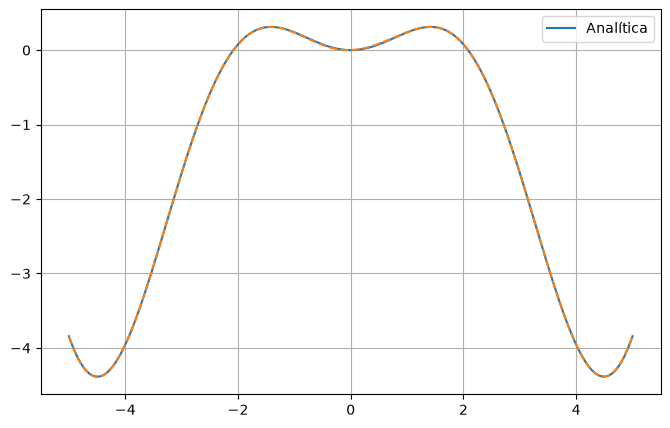

In [82]:
plt.figure(figsize=(8,5))
plt.plot(x,y_exact,label="Analítica")
plt.plot(x,y_nn,'--')
plt.legend()
plt.grid()
plt.show()

In [83]:
error = np.abs(y_exact - y_nn.flatten())

print("Error máximo:", np.max(error))
print("Error medio:", np.mean(error))

Error máximo: 0.009230116002407085
Error medio: 0.0022340965921203797


In [84]:
print(history[-1])

0.0008576833


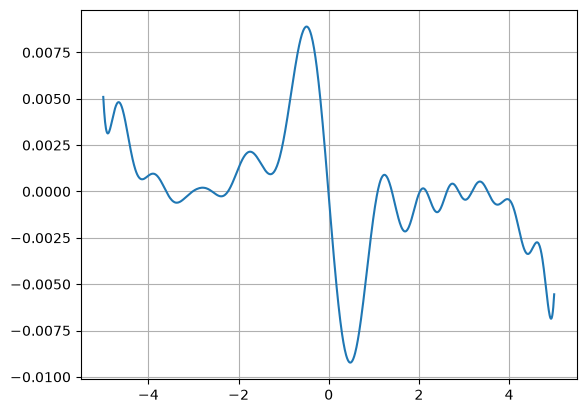

In [85]:
plt.plot(x,y_exact - y_nn.flatten())
plt.grid()
plt.show()

### B )

In [98]:
with tf.GradientTape(persistent=True) as tape:
    tape.watch(dominio)
    y = model_ED(dominio)
    dy_dx = tape.gradient(y,dominio)
d2y_dx2 = tape.gradient(
    dy_dx,
    dominio
)


In [99]:
def loss_fn_2():

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(dominio)
        y = model_ED(dominio)
        dy_dx = tape.gradient(
            y,
            dominio
        )

    d2y_dx2 = tape.gradient(
        dy_dx,
        dominio
    )

    residual = d2y_dx2 + y

    ode_loss = tf.reduce_mean(
        residual**2
    )

    x0 = tf.constant([[0.0]])

    with tf.GradientTape() as tape0:
        tape0.watch(x0)
        y0 = model_ED(x0)
    dy0 = tape0.gradient(
        y0,
        x0
    )
    ic_loss = (
        tf.reduce_mean((y0 - 1.0)**2)
        +
        tf.reduce_mean((dy0 + 0.5)**2)
    )

    return ode_loss + ic_loss

In [100]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
history = []

for epoch in range(200):

    with tf.GradientTape() as tape:

        loss = loss_fn_2()

    grads = tape.gradient(
        loss,
        model_ED.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            grads,
            model_ED.trainable_variables
        )
    )

    history.append(loss.numpy())

    if epoch % 20 == 0:
        print(epoch,loss.numpy())

0 0.0007410338
20 0.0006445789
40 0.00047717
60 0.00036413997
80 0.00030081542
100 0.0002514704
120 0.0002133989
140 0.00018333505
160 0.00015928785
180 0.00013978743


In [101]:
x = np.linspace(-5,5,1000)
y_exact = (np.cos(x)- 0.5*np.sin(x))

In [94]:
y_pred = model_ED.predict(
    x.reshape(-1,1),
    verbose=0
)

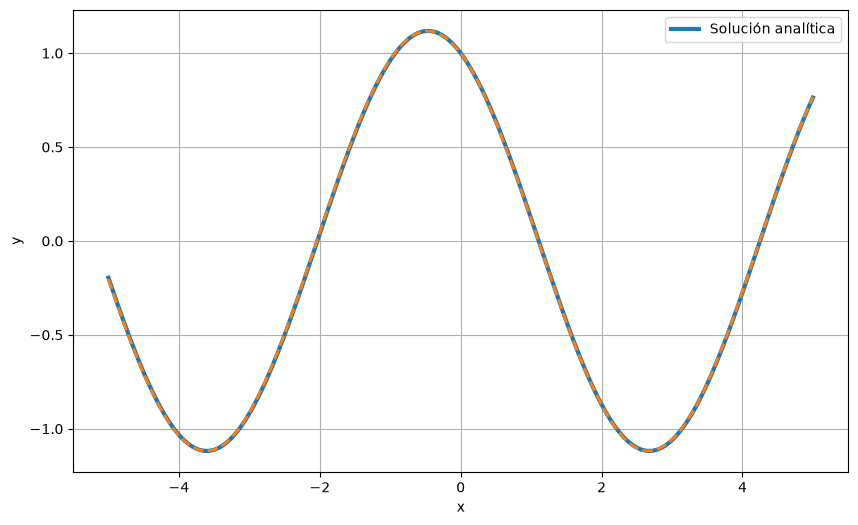

In [97]:
plt.figure(figsize=(10,6))

plt.plot(x,y_exact,linewidth=3,label="Solución analítica")
plt.plot(x,y_pred,"--",linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

In [40]:
error = np.abs(
    y_exact - y_pred.flatten()
)

print("Error máximo:", np.max(error))
print("Error medio:", np.mean(error))

Error máximo: 0.0076093109940340575
Error medio: 0.0028478248081221774


In [41]:
print(history[-1])

0.0008576833


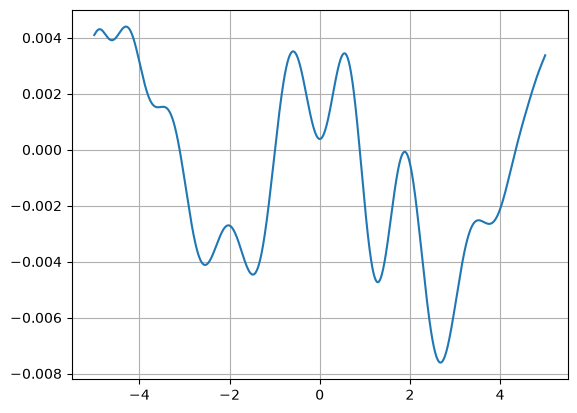

In [ ]:
plt.plot(x,y_exact - y_pred.flatten())
plt.grid()
plt.show()